# Single-zone Thailand example

A single-zone (Thailand) capacity-expansion run with **13 cascading Mekong-basin reservoirs** -- Bhumibol, Sirikit, Srinagarind, Vajiralongkorn, Rajjaprabha, etc. Migrated from the v1.4-era xlsx dataset to the v1.9 long-format CSV schema; all per-station reservoir physics (head, tailrace-discharge curves, forebay-volume curves) preserved.

**Run the solve from the command line** (the dataset is large -- 1M+ variables -- so a full solve takes ~30 min):

```bash
cd examples/thailand
python -m prepshot
```

The cells below explore the dataset shape and read the result NetCDF. They run fast (no solve).

In [1]:
import pathlib

# Walk up to find the example dir (containing config.json + input/).
this_dir = pathlib.Path.cwd()
while not (this_dir / 'config.json').exists() or not (this_dir / 'input').is_dir():
    if this_dir == this_dir.parent:
        raise RuntimeError(
            'Could not locate the example dir; run from inside '
            'examples/thailand/.'
        )
    this_dir = this_dir.parent
INPUT = this_dir / 'input'
print(f'Example dir: {this_dir}')
print(f'Input:       {INPUT}')

Example dir: /Users/energy/01-doing/PREP-SHOT-tutorial/PREP-SHOT/examples/thailand
Input:       /Users/energy/01-doing/PREP-SHOT-tutorial/PREP-SHOT/examples/thailand/input


## Existing fleet (2023)

Thailand's installed capacity in the start year, with `Large Hydropower` allocated across the 13 reservoir techs by their rated capacity.

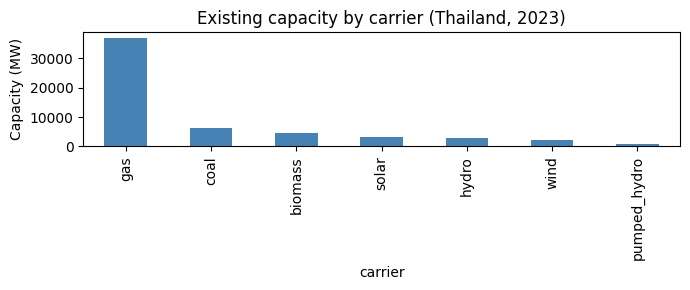

carrier
gas             36993.0
coal             6138.0
biomass          4705.0
solar            3186.0
hydro            2925.0
wind             2092.0
pumped_hydro     1000.0
Name: capacity, dtype: float64

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

fleet = pd.read_csv(INPUT / 'tech_existing.csv')
registry = pd.read_csv(INPUT / 'tech_registry.csv')
merged = fleet.merge(registry[['tech', 'carrier']], on='tech')
by_carrier = merged.groupby('carrier')['capacity'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 3))
by_carrier.plot.bar(ax=ax, color='steelblue')
ax.set_ylabel('Capacity (MW)')
ax.set_title('Existing capacity by carrier (Thailand, 2023)')
fig.tight_layout()
plt.show()
by_carrier.round(0)

## Per-station hydropower characteristics

Each reservoir is modeled with its own head, capacity, and operational bounds -- the feature that distinguishes PREP-SHOT from PyPSA / GenX.

In [3]:
head = pd.read_csv(INPUT / 'reservoir_head.csv')
cap  = pd.read_csv(INPUT / 'reservoir_capacity_max.csv')
merged = (
    head[['tech', 'head']]
    .merge(cap[['tech', 'capacity_max']], on='tech')
    .sort_values('capacity_max', ascending=False)
)
merged.round(1)

,tech,head,capacity_max
0,Bhumibol,154.0,779.2
10,Srinagarind,140.0,720.0
1,Sirikit,113.6,500.0
12,Vajiralongkorn,92.0,300.0
9,Rajjaprabha,94.0,240.0
4,Pak_Mun,17.0,136.0
7,Bang_Lang,85.0,84.0
2,Chulabhorn,70.0,40.0
11,Tha_Thung_Na,30.0,39.0
5,Siridhorn,42.0,36.0


## Inspect a solve (after running `python -m prepshot`)

Once you've run the CLI command above and it has written `output/baseline.nc`, the cell below opens it. Skip if you haven't run the solve yet.

In [4]:
import xarray as xr

nc_path = this_dir / 'output' / 'baseline.nc'
if not nc_path.exists():
    print(f'No NetCDF at {nc_path}. Run `python -m prepshot` from {this_dir} first.')
else:
    ds = xr.open_dataset(nc_path, engine='h5netcdf')
    print(f'Total cost (NPV): ${float(ds.cost):,.0f}')
    print(f'Variables: {sorted(ds.data_vars)[:6]} ...')

Total cost (NPV): $6,086,053,487
Variables: ['carbon', 'carbon_breakdown', 'charge', 'cost', 'cost_fix', 'cost_fix_breakdown'] ...


## Where to next

- [Quickstart notebook](../../doc/source/Quickstart.ipynb) -- the canonical 5-minute walkthrough on a smaller 3-zone synthetic dataset.
- [Southeast Asia notebook](../southeast_asia/SoutheastAsia.ipynb) -- a 5-country regional case with 57 reservoirs.
- [Model Inputs/Outputs](../../doc/source/Model_input_output.rst) -- every file in `input/` documented.